# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:

Altere o código abaixo de acordo com seu diretório.

In [48]:

caminho = r"C:\Users\User\Desktop\MODULO7_PROJETOFINAL_BASE_SUPERMERCADO_MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv"

df = pd.read_csv(caminho, sep=',')  # ou sep=',' dependendo do separador
print(df.head(10))

                                            title       Marca  Preco_Normal  \
Pack 12 un               Leche extra proteína 1 L  Loncoleche         19788   
Pack 12 un    Leche chocolate receta original 1 L     Soprole         18228   
Pack 12 un     Leche semidescremada chocolate 1 L     Soprole         18228   
Pack 12 un      Leche semidescremada frutilla 1 L     Soprole         18228   
Pack 12 un        Leche sin lactosa chocolate 1 L  Loncoleche         17988   
Pack 12 un         Leche sin lactosa frutilla 1 L  Loncoleche         17988   
Pack 12 un   Leche saborizada light chocolate 1 L  Loncoleche         17988   
Pack 12 un          Leche saborizada frutilla 1 L       Colun         17388   
Pack 12 un          Leche saborizada vainilla 1 L       Colun         17388   
Pack 12 un            Leche saborizada manjar 1 L       Colun         17388   

            Preco_Desconto  Preco_Anterior Desconto Categoria  
Pack 12 un               0               0        0   lacteos  
Pa

Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [49]:
 estatisticas = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median']).reset_index()    #Seu código aqui para a média


In [50]:
estatisticas['comparacao'] = estatisticas.apply(
    lambda row: 'média acima da mediana' if row['mean'] > row['median'] else
                ('média abaixo da mediana' if row['mean'] < row['median'] else 'média igual à mediana'),
    axis=1
)

print(estatisticas)    #Seu código aqui para a mediana


                    Categoria         mean  median              comparacao
0  belleza-y-cuidado-personal  2406.887640  1990.0  média acima da mediana
1          comidas-preparadas  3873.333333  3640.0  média acima da mediana
2                  congelados  2673.647059     0.0  média acima da mediana
3                      frutas  2240.000000  2240.0   média igual à mediana
4        instantaneos-y-sopas  1499.000000  1499.0   média igual à mediana
5                     lacteos  6978.673913  3174.0  média acima da mediana
6                    verduras  1106.363636  1040.0  média acima da mediana


Digite aqui as categorias: beleza e cuidado-pessoal, comidas-preparadas, congelados, lacteos, verduras, instantaneos e sopas.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [51]:
estatisticas = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median', 'std']).reset_index()    #Seu código aqui
estatisticas['comparacao'] = estatisticas.apply(
    lambda row: 'média acima da mediana' if row['mean'] > row['median'] else
                ('média abaixo da mediana' if row['mean'] < row['median'] else 'média igual à mediana'),
    axis=1
)

print(estatisticas)

                    Categoria         mean  median          std  \
0  belleza-y-cuidado-personal  2406.887640  1990.0  2756.029186   
1          comidas-preparadas  3873.333333  3640.0   770.497675   
2                  congelados  2673.647059     0.0  3504.242802   
3                      frutas  2240.000000  2240.0    70.710678   
4        instantaneos-y-sopas  1499.000000  1499.0          NaN   
5                     lacteos  6978.673913  3174.0  5985.454942   
6                    verduras  1106.363636  1040.0   464.978704   

               comparacao  
0  média acima da mediana  
1  média acima da mediana  
2  média acima da mediana  
3   média igual à mediana  
4   média igual à mediana  
5  média acima da mediana  
6  média acima da mediana  


Digite nesse campo o comportamento que você identificou.

Categorias com maior desvio padrão:

lácteos (std ≈ 5985)
congelados (std ≈ 3504)
beleza e cuidado pessoal (std ≈ 2756)
Essas categorias têm preços muito variados, indicando que dentro delas existem produtos baratos e outros muito caros. Isso gera uma dispersão grande.

Comportamento da média vs. mediana:

Nessas categorias de maior desvio, a média está acima da mediana.
Isso sugere que existem valores extremos (produtos caros) puxando a média para cima, enquanto a mediana permanece mais baixa, refletindo o “centro” da distribuição.
Em outras palavras: há produtos premium que distorcem a média, mas a maioria dos itens está em faixas de preço menores.

Categorias com baixo desvio padrão:

frutas (std ≈ 70) e verduras (std ≈ 465)
Aqui os preços são mais homogêneos. A média e a mediana praticamente coincidem, mostrando estabilidade e pouca influência de valores extremos.

Categoria com mediana zero (congelados):

Isso indica que muitos produtos podem estar com preço registrado como “0” (talvez erro de base ou ausência de desconto).
A média ainda aparece positiva, puxada por alguns valores altos, o que reforça a ideia de distorção.


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

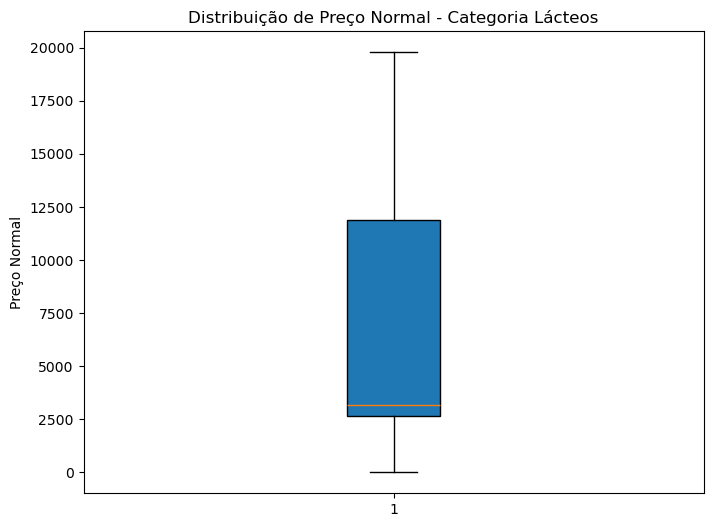

In [52]:
df_lacteos = df[df['Categoria'] == 'lacteos']

plt.figure(figsize=(8,6))
plt.boxplot(df_lacteos['Preco_Normal'], vert=True, patch_artist=True)
plt.title("Distribuição de Preço Normal - Categoria Lácteos")
plt.ylabel("Preço Normal")
plt.show()   


# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

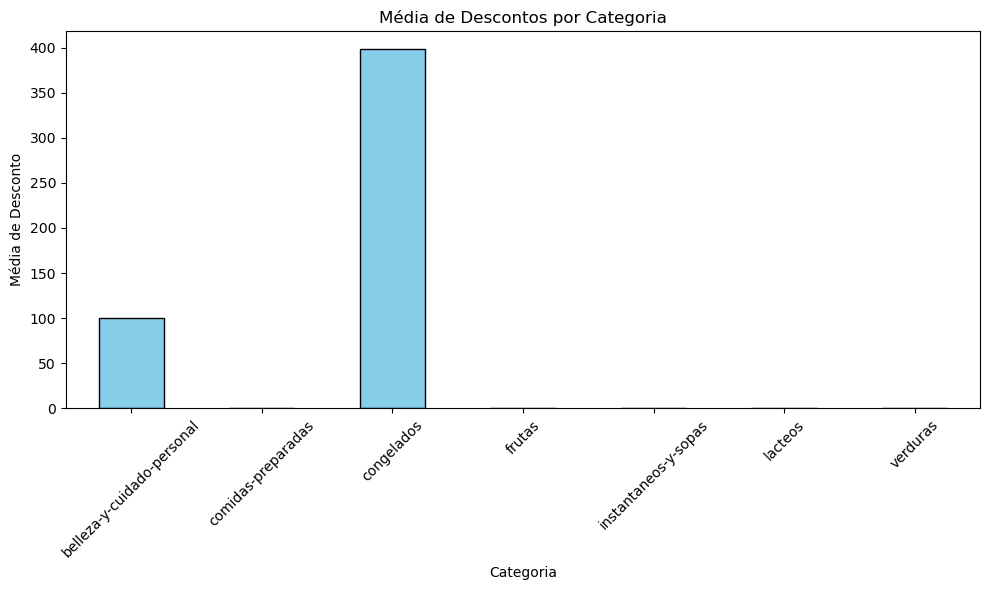

In [54]:
# Converte a coluna 'Desconto' para numérica (valores inválidos viram NaN)
df['Desconto'] = pd.to_numeric(df['Desconto'], errors='coerce')

# Calcula a média de descontos por categoria
media_descontos = df.groupby('Categoria')['Desconto'].mean()

# Plota gráfico de barras
plt.figure(figsize=(10,6))
media_descontos.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Média de Descontos por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Média de Desconto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

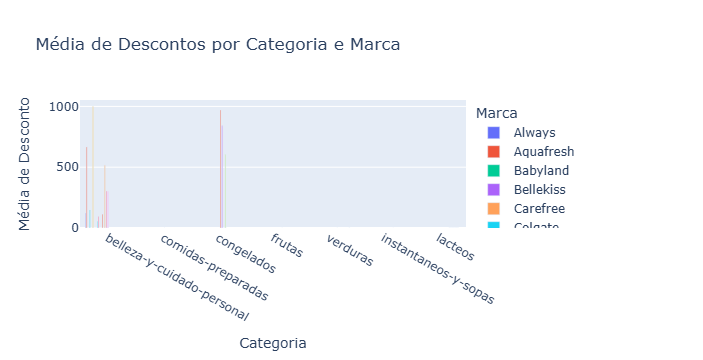

In [55]:
# Converte a coluna Desconto para numérica
df['Desconto'] = pd.to_numeric(df['Desconto'], errors='coerce')

# Agrupa por Categoria e Marca, calculando a média de desconto
media_descontos = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

# Cria gráfico interativo de barras agrupadas
fig = px.bar(
    media_descontos,
    x="Categoria",
    y="Desconto",
    color="Marca",
    barmode="group",
    title="Média de Descontos por Categoria e Marca",
    labels={"Desconto": "Média de Desconto", "Categoria": "Categoria"}
)

fig.show()
